<a href="https://colab.research.google.com/github/asnaraliya/ICT/blob/main/DataAquisition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import sqlite3


In [6]:
# Population (CSV)
population = pd.read_csv('/content/population.csv')

# GDP (Excel)
gdp = pd.read_excel('/content/gdp.xlsx')

# Internet Users (JSON)
internet_users = pd.read_json('/content/internet_users.json')

# Literacy Rate (XML)
literacy_rate = pd.read_xml('/content/literacy_rate.xml')

# Quick check
print(population.head())
print(gdp.head())
print(internet_users.head())
print(literacy_rate.head())


         country  population
0  United States   331002651
1          China  1411778724
2          India  1380004385
3          Japan   125836021
4        Germany    83240525
         Country       GDP
0  United States  30500000
1          China  19230000
2          India   4187000
3          Japan   4180000
4        Germany   4744000
         country  internet_users
0  United States       312000000
1          China      1080000000
2          India       850000000
3          Japan       118000000
4        Germany        79000000
            name  literacy_rate
0  United States           99.0
1          China           97.2
2          India           77.7
3          Japan           99.0
4        Germany           99.0


In [8]:
# Rename columns
population.rename(columns={'country':'country','population':'population'}, inplace=True)
gdp.rename(columns={'Country':'country','GDP':'gdp'}, inplace=True)
internet_users.rename(columns={'country':'country','internet_users':'internet_users'}, inplace=True)
literacy_rate.rename(columns={'name':'country','literacy_rate':'literacy_rate'}, inplace=True)

# Show column names after renaming
print("Population columns:", population.columns.tolist())
print("GDP columns:", gdp.columns.tolist())
print("Internet Users columns:", internet_users.columns.tolist())
print("Literacy Rate columns:", literacy_rate.columns.tolist())


Population columns: ['country', 'population']
GDP columns: ['country', 'gdp']
Internet Users columns: ['country', 'internet_users']
Literacy Rate columns: ['country', 'literacy_rate']


In [9]:
# Convert all numeric fields to proper numeric types
population['population'] = pd.to_numeric(population['population'], errors='coerce')
gdp['gdp'] = pd.to_numeric(gdp['gdp'], errors='coerce')
internet_users['internet_users'] = pd.to_numeric(internet_users['internet_users'], errors='coerce')
literacy_rate['literacy_rate'] = pd.to_numeric(literacy_rate['literacy_rate'], errors='coerce')

# ✅ Show dtypes after conversion
print("Population dtypes:\n", population.dtypes, "\n")
print("GDP dtypes:\n", gdp.dtypes, "\n")
print("Internet Users dtypes:\n", internet_users.dtypes, "\n")
print("Literacy Rate dtypes:\n", literacy_rate.dtypes, "\n")


Population dtypes:
 country       object
population     int64
dtype: object 

GDP dtypes:
 country    object
gdp         int64
dtype: object 

Internet Users dtypes:
 country           object
internet_users     int64
dtype: object 

Literacy Rate dtypes:
 country           object
literacy_rate    float64
dtype: object 



In [10]:
# Merge all datasets on 'country'
merged = population.merge(gdp, on='country') \
                   .merge(internet_users, on='country') \
                   .merge(literacy_rate, on='country')

# ✅ Show merged DataFrame info
print("Merged dataset shape:", merged.shape)
print("Merged dataset columns:", merged.columns.tolist())
print(merged.head())


Merged dataset shape: (25, 5)
Merged dataset columns: ['country', 'population', 'gdp', 'internet_users', 'literacy_rate']
         country  population       gdp  internet_users  literacy_rate
0  United States   331002651  30500000       312000000           99.0
1          China  1411778724  19230000      1080000000           97.2
2          India  1380004385   4187000       850000000           77.7
3          Japan   125836021   4180000       118000000           99.0
4        Germany    83240525   4744000        79000000           99.0


In [11]:
# Add Internet Penetration and GDP per Capita
merged['internet_penetration'] = (merged['internet_users'] / merged['population'] * 100).round(2)
merged['gdp_per_capita'] = (merged['gdp'] / merged['population']).round(2)

# ✅ Show new columns
print("Calculated columns added:")
print(merged[['country','internet_penetration','gdp_per_capita']].head())


Calculated columns added:
         country  internet_penetration  gdp_per_capita
0  United States                 94.26            0.09
1          China                 76.50            0.01
2          India                 61.59            0.00
3          Japan                 93.77            0.03
4        Germany                 94.91            0.06


In [12]:
# Create SQLite database and store merged dataset
conn = sqlite3.connect('country_stats.db')
merged.to_sql('country_statistics', conn, if_exists='replace', index=False)

# ✅ Verify by querying first 5 rows
check = pd.read_sql("SELECT * FROM country_statistics LIMIT 5;", conn)
print("First 5 rows from SQLite table:\n", check)


First 5 rows from SQLite table:
          country  population       gdp  internet_users  literacy_rate  \
0  United States   331002651  30500000       312000000           99.0   
1          China  1411778724  19230000      1080000000           97.2   
2          India  1380004385   4187000       850000000           77.7   
3          Japan   125836021   4180000       118000000           99.0   
4        Germany    83240525   4744000        79000000           99.0   

   internet_penetration  gdp_per_capita  
0                 94.26            0.09  
1                 76.50            0.01  
2                 61.59            0.00  
3                 93.77            0.03  
4                 94.91            0.06  


In [14]:
print("Top 5 by GDP:\n", merged.nlargest(5, 'gdp')[['country','gdp']], "\n")
print("Top 5 by Population:\n", merged.nlargest(5, 'population')[['country','population']], "\n")
print("Average Literacy Rate:", merged['literacy_rate'].mean(), "\n")
print("Countries Literacy > 90%:\n", merged[merged['literacy_rate'] > 90]['country'].tolist(), "\n")
print("Internet Penetration > 70%:\n", merged[merged['internet_penetration'] > 70]['country'].tolist(), "\n")
print("Top 5 by GDP per Capita:\n", merged.nlargest(5, 'gdp_per_capita')[['country','gdp_per_capita']], "\n")
print("Total Population:", merged['population'].sum(), "\n")
print("Average Internet Penetration:", merged['internet_penetration'].mean(), "\n")
print("Highest Internet Users:", merged.loc[merged['internet_users'].idxmax(), 'country'], "\n")
print("Correlation Literacy vs Internet Penetration:", merged['literacy_rate'].corr(merged['internet_penetration']), "\n")


Top 5 by GDP:
          country       gdp
0  United States  30500000
1          China  19230000
4        Germany   4744000
2          India   4187000
3          Japan   4180000 

Top 5 by Population:
           country  population
1           China  1411778724
2           India  1380004385
0   United States   331002651
15      Indonesia   273523615
10         Brazil   212559417 

Average Literacy Rate: 97.248 

Countries Literacy > 90%:
 ['United States', 'China', 'Japan', 'Germany', 'United Kingdom', 'France', 'Italy', 'Canada', 'Australia', 'Brazil', 'Russia', 'South Korea', 'Spain', 'Mexico', 'Indonesia', 'Saudi Arabia', 'Turkey', 'South Africa', 'Argentina', 'Netherlands', 'Switzerland', 'Sweden', 'Norway', 'Singapore'] 

Internet Penetration > 70%:
 ['United States', 'China', 'Japan', 'Germany', 'United Kingdom', 'France', 'Italy', 'Canada', 'Australia', 'Brazil', 'Russia', 'South Korea', 'Spain', 'Mexico', 'Indonesia', 'Saudi Arabia', 'Turkey', 'South Africa', 'Argentina', 'Nethe

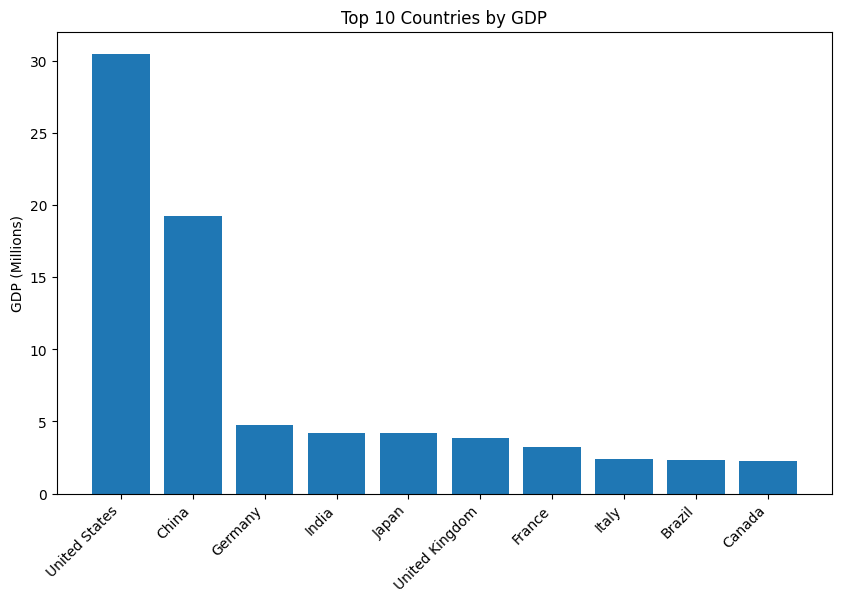

In [15]:
import matplotlib.pyplot as plt

top_gdp = merged.nlargest(10, 'gdp')
plt.figure(figsize=(10,6))
plt.bar(top_gdp['country'], top_gdp['gdp']/1e6)  # scale to millions
plt.xticks(rotation=45, ha='right')
plt.ylabel("GDP (Millions)")
plt.title("Top 10 Countries by GDP")
plt.show()


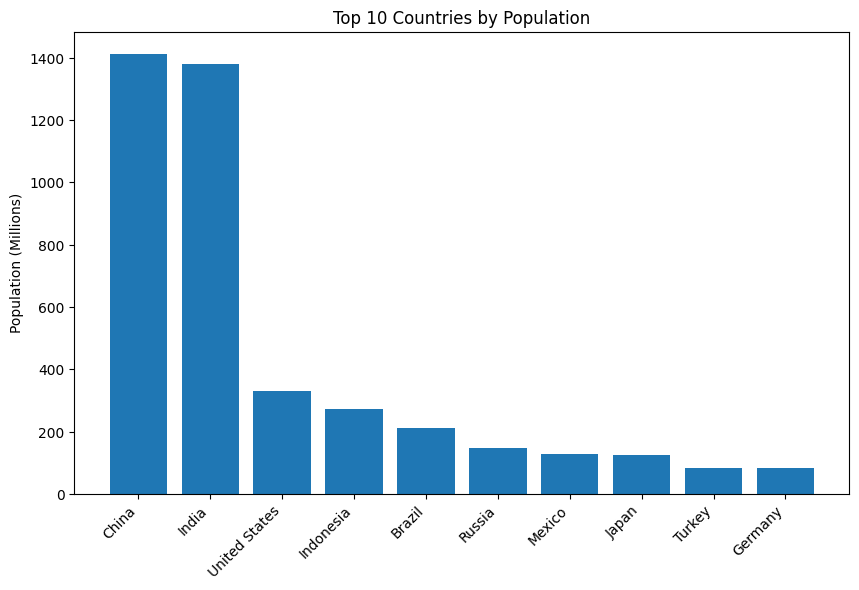

In [16]:
top_pop = merged.nlargest(10, 'population')
plt.figure(figsize=(10,6))
plt.bar(top_pop['country'], top_pop['population']/1e6)  # scale to millions
plt.xticks(rotation=45, ha='right')
plt.ylabel("Population (Millions)")
plt.title("Top 10 Countries by Population")
plt.show()


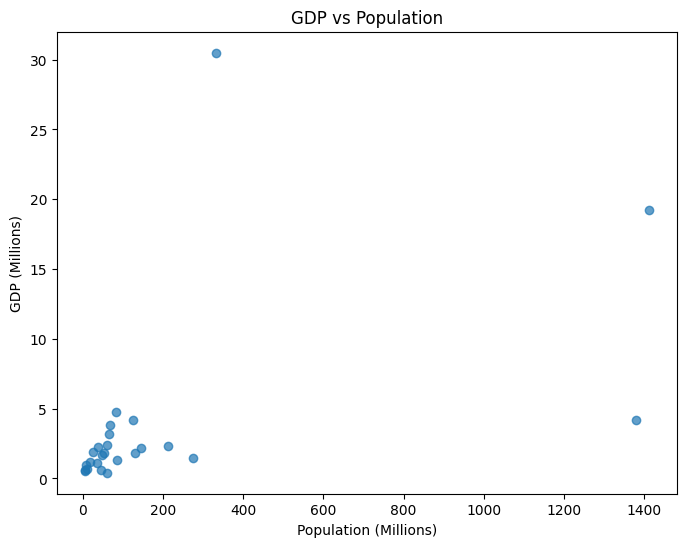

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(merged['population']/1e6, merged['gdp']/1e6, alpha=0.7)
plt.xlabel("Population (Millions)")
plt.ylabel("GDP (Millions)")
plt.title("GDP vs Population")
plt.show()


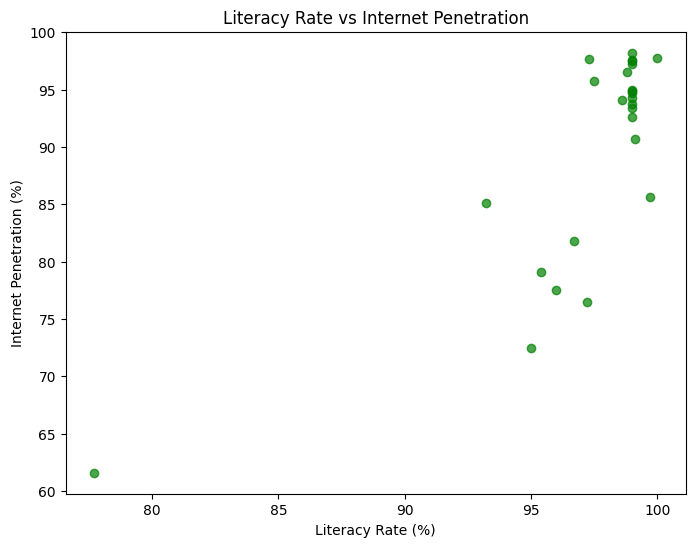

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(merged['literacy_rate'], merged['internet_penetration'], alpha=0.7, color='green')
plt.xlabel("Literacy Rate (%)")
plt.ylabel("Internet Penetration (%)")
plt.title("Literacy Rate vs Internet Penetration")
plt.show()


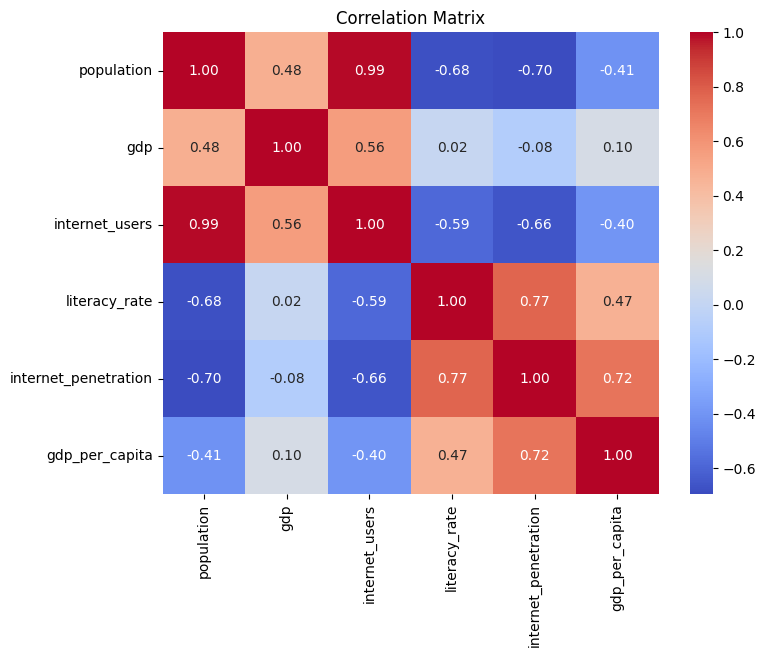

In [19]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(merged[['population','gdp','internet_users','literacy_rate',
                    'internet_penetration','gdp_per_capita']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()
